In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("../dataset/Phishing_Email.csv")

# Remove unwanted column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns
df = df.rename(columns={
    "Email Text": "text",
    "Email Type": "label"
})

# Remove missing values
df = df.dropna()

# Remove duplicate emails
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Display information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["label"].value_counts())

df.head()

Shape: (17538, 2)

Columns:
Index(['text', 'label'], dtype='str')

Missing Values:
text     0
label    0
dtype: int64

Class Distribution:
label
Safe Email        10980
Phishing Email     6558
Name: count, dtype: int64


,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
# Convert labels to numbers
df["label"] = df["label"].str.strip()

df["label"] = df["label"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Verify conversion
print(df["label"].value_counts())
df.head()

label
0    10980
1     6558
Name: count, dtype: int64


,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [6]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources (only downloads the first time)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK setup completed successfully!")

NLTK setup completed successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("All NLTK packages downloaded successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...


All NLTK packages downloaded successfully!


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [47]:
# Create lemmatizer and stopword list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Function to clean and preprocess email text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(words)

# Apply preprocessing
df["processed_text"] = df["text"].apply(preprocess_text)

# Display results
df[["text", "processed_text"]].head()

,text,processed_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term name im...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still available assist ro...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low price lower drapery se...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["processed_text"])
y = df["label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (14030, 5000)
Testing Data Shape  : (3508, 5000)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.977195,0.963855,0.975610,0.969697
4,MLP Classifier,0.974059,0.961451,0.969512,0.965465
0,Logistic Regression,0.970639,0.967517,0.953506,0.960461
3,Random Forest,0.969498,0.957479,0.961128,0.959300
1,Naive Bayes,0.963512,0.956086,0.945884,0.950958


In [11]:
import joblib

# Train the final Linear SVM model
final_model = LinearSVC()
final_model.fit(X_train, y_train)

# Save the trained model
joblib.dump(final_model, "../model/phishing_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "../model/tfidf_vectorizer.pkl")

print("✅ Model saved successfully!")
print("✅ TF-IDF Vectorizer saved successfully!")

✅ Model saved successfully!
✅ TF-IDF Vectorizer saved successfully!


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions using the final model
y_pred = final_model.predict(X_test)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2196
           1       0.96      0.98      0.97      1312

    accuracy                           0.98      3508
   macro avg       0.97      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508



In [39]:
def predict_email(email):

    processed = preprocess_text(email)

    vector = tfidf.transform([processed])

    prediction = final_model.predict(vector)[0]

    if prediction == 1:
        print("🚨 Phishing Email")
    else:
        print("✅ Safe Email")

In [45]:
cleaned_df = df[["processed_text", "label"]]

In [46]:
cleaned_df.to_csv("../dataset/cleaned_dataset.csv", index=False)

In [40]:
predict_email("""
Dear Customer,

Your SBI account has been temporarily suspended.
Click the link below immediately to verify your account.

http://secure-sbi-login.xyz

Failure to verify within 24 hours will permanently block your account.
""")

🚨 Phishing Email


In [41]:
predict_email("""
Hi Akash,

The project meeting has been moved to tomorrow at 10 AM.

Please bring your updated presentation.

Regards,
Project Guide
""")

✅ Safe Email


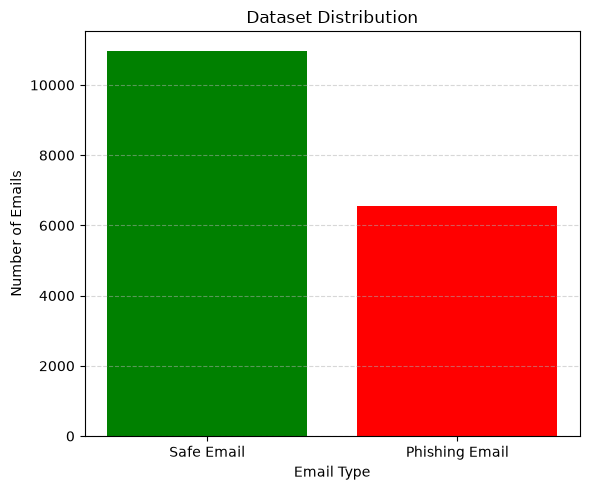

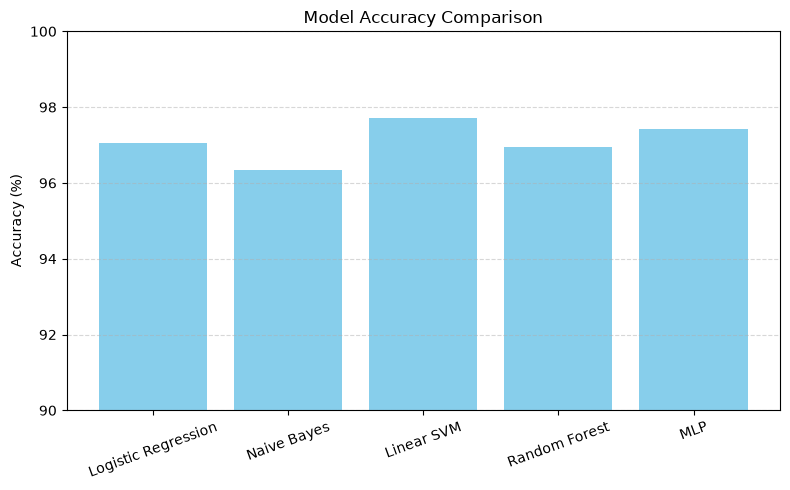

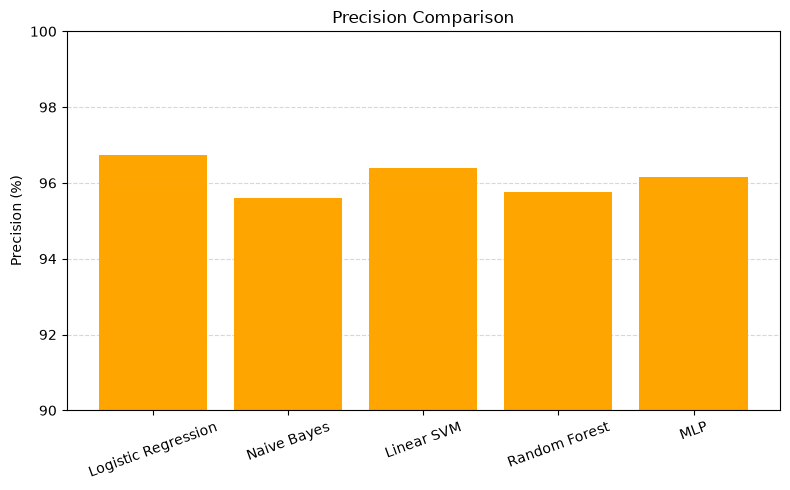

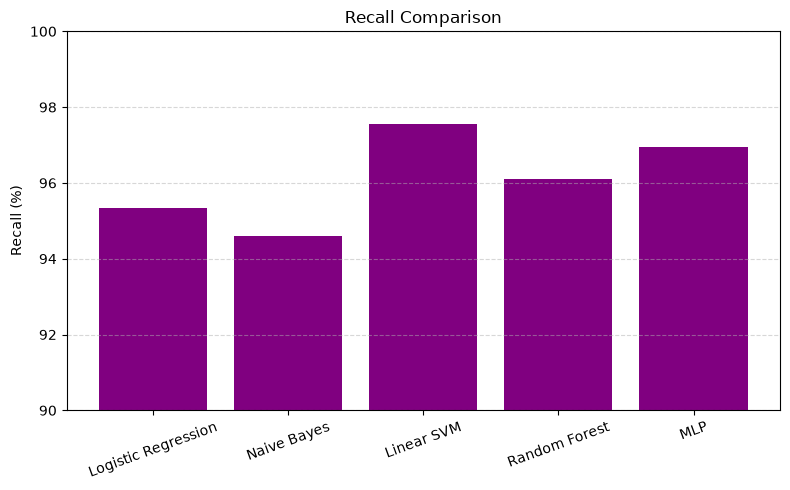

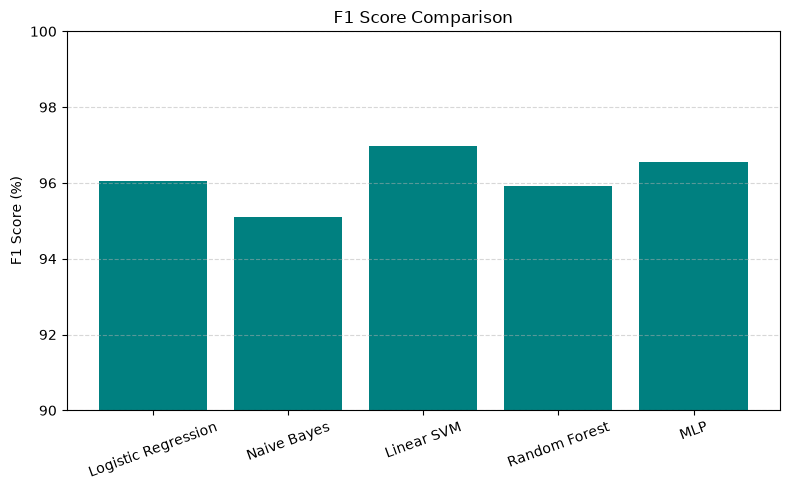

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
# =====================================================
# Dataset Distribution
# =====================================================
counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(["Safe Email", "Phishing Email"], counts.values, color=["green","red"])
plt.title("Dataset Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================
# Model Performance Results
# =====================================================
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest",
        "MLP"
    ],
    "Accuracy": [97.06, 96.35, 97.72, 96.95, 97.41],
    "Precision": [96.75, 95.61, 96.39, 95.75, 96.15],
    "Recall": [95.35, 94.59, 97.56, 96.11, 96.95],
    "F1 Score": [96.05, 95.10, 96.97, 95.93, 96.55]
})

# =====================================================
# Accuracy Comparison
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"], color="skyblue")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================
# Precision Comparison
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Precision"], color="orange")
plt.title("Precision Comparison")
plt.ylabel("Precision (%)")
plt.ylim(90, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================
# Recall Comparison
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Recall"], color="purple")
plt.title("Recall Comparison")
plt.ylabel("Recall (%)")
plt.ylim(90, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================
# F1 Score Comparison
# =====================================================
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["F1 Score"], color="teal")
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score (%)")
plt.ylim(90, 100)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



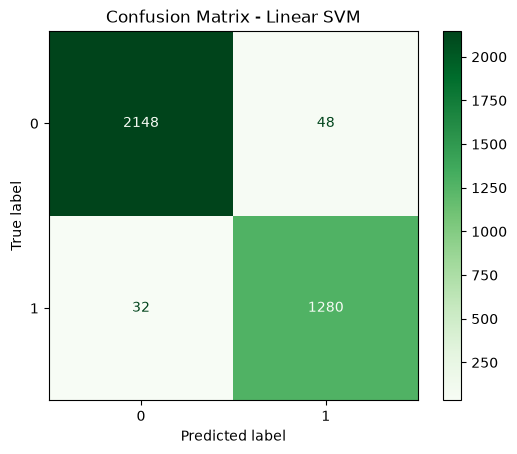

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()